# Bike Rental Regression & Interaction Analysis

Cleaned and reproducible portfolio version of a university machine-learning laboratory assignment.

**Reproducibility choices:** fixed random seeds, train-only preprocessing/feature selection, held-out evaluation, and explicit dataset paths.

## 0. Setup and data validation

The bike-sharing dataset contains hourly rental counts, weather variables, and calendar information for 2011–2012. The original `weekday` encoding is not used to define weekends; weekends are derived directly from the date.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42


def find_project_root():
    here = Path.cwd().resolve()
    for candidate in [here, here.parent, here.parent.parent]:
        if (candidate / "data" / "hour.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find data/hour.csv. Run the notebook from the repository or notebooks directory.")

ROOT = find_project_root()
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

bike = pd.read_csv(DATA_DIR / "hour.csv")
bike["dteday"] = pd.to_datetime(bike["dteday"])
bike["weekend"] = (bike["dteday"].dt.dayofweek >= 5).astype(int)

assert bike.isna().sum().sum() == 0
assert (bike["cnt"] == bike["casual"] + bike["registered"]).all()
print("Shape:", bike.shape)
print("Date range:", bike["dteday"].min().date(), "to", bike["dteday"].max().date())
display(bike.head())

Shape: (17379, 18)
Date range: 2011-01-01 to 2012-12-31


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,weekend
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,1
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,1
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,1
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,1
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,1


## 1. How does the temperature effect vary across the 24-hour cycle?

A linear model is fitted on 2011 data with an hour × temperature interaction and calendar/weather controls. The interaction coefficients are converted into an hour-specific temperature slope. The model is then evaluated on 2012 data.

2012 RMSE: 153.49
2012 R²:   0.460


,hour,temperature_slope
18,18,478.032369
17,17,468.529823
19,19,381.086854
20,20,279.077315
16,16,260.789000


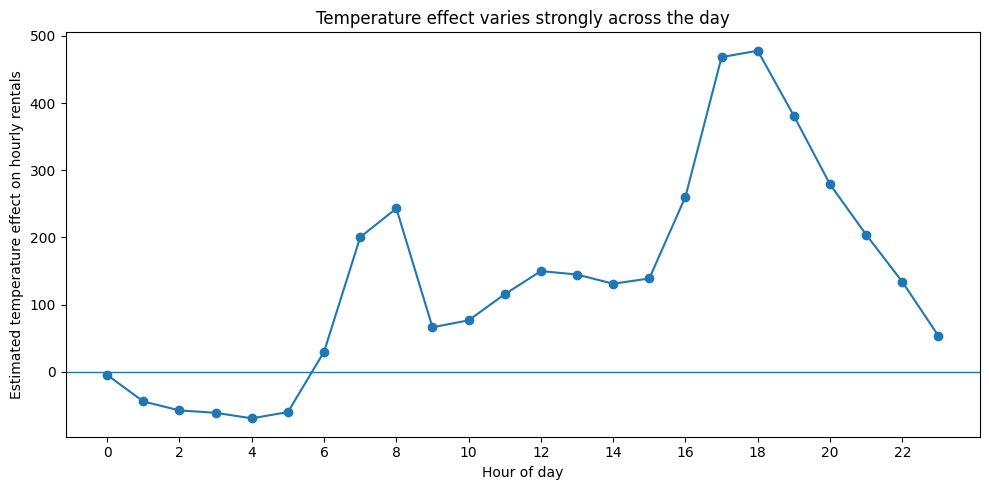

In [2]:
train_2011 = bike[bike["yr"] == 0].copy()
test_2012 = bike[bike["yr"] == 1].copy()

formula = (
    "cnt ~ C(hr) * temp + C(season) + C(mnth) + C(weekday) + "
    "workingday + holiday + C(weathersit) + hum + windspeed"
)
temp_hour_model = smf.ols(formula, data=train_2011).fit()
test_pred = temp_hour_model.predict(test_2012)

print(f"2012 RMSE: {mean_squared_error(test_2012['cnt'], test_pred) ** 0.5:.2f}")
print(f"2012 R²:   {r2_score(test_2012['cnt'], test_pred):.3f}")

base_slope = temp_hour_model.params["temp"]
hour_slopes = []
for hour in range(24):
    interaction = temp_hour_model.params.get(f"C(hr)[T.{hour}]:temp", 0.0)
    hour_slopes.append(base_slope + interaction)

slope_df = pd.DataFrame({"hour": range(24), "temperature_slope": hour_slopes})
display(slope_df.sort_values("temperature_slope", ascending=False).head())

plt.figure(figsize=(10, 5))
plt.plot(slope_df["hour"], slope_df["temperature_slope"], marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Hour of day")
plt.ylabel("Estimated temperature effect on hourly rentals")
plt.title("Temperature effect varies strongly across the day")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig(FIG_DIR / "temperature_effect_by_hour.png", dpi=160)
plt.show()

**Interpretation.** In this model, temperature has little or even negative association with rentals during the overnight hours, while the estimated effect is strongest around the evening commute. This is an interaction effect, not a causal estimate.

## 2. Does wind speed deter leisure riders more than registered riders?

Two comparable models are trained on 2011 and tested on 2012. Targets are transformed with `log1p`, so the standardized wind-speed coefficients are more comparable across casual and registered counts.

,rider_type,test_R2_log_target,standardized_wind_coefficient
0,casual,0.785306,-0.042238
1,registered,0.673987,-0.011364


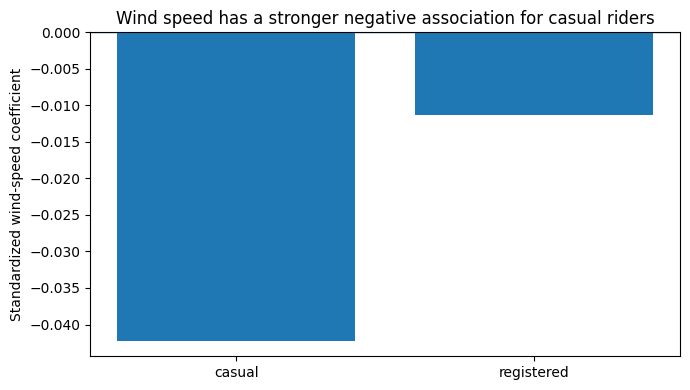

In [3]:
categorical = ["hr", "season", "mnth", "weekday", "workingday", "holiday", "weathersit"]
wind_features = ["windspeed", "temp"] + categorical

wind_preprocess = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical),
    ("numeric", StandardScaler(), ["windspeed", "temp"]),
])

wind_results = []
for target in ["casual", "registered"]:
    model = Pipeline([
        ("preprocess", wind_preprocess),
        ("model", LinearRegression()),
    ])
    model.fit(train_2011[wind_features], np.log1p(train_2011[target]))
    pred = model.predict(test_2012[wind_features])
    feature_names = list(model.named_steps["preprocess"].get_feature_names_out())
    wind_idx = feature_names.index("numeric__windspeed")
    wind_coef = model.named_steps["model"].coef_[wind_idx]
    wind_results.append({
        "rider_type": target,
        "test_R2_log_target": r2_score(np.log1p(test_2012[target]), pred),
        "standardized_wind_coefficient": wind_coef,
    })

wind_results = pd.DataFrame(wind_results)
display(wind_results)

plt.figure(figsize=(7, 4))
plt.bar(wind_results["rider_type"], wind_results["standardized_wind_coefficient"])
plt.axhline(0, linewidth=1)
plt.ylabel("Standardized wind-speed coefficient")
plt.title("Wind speed has a stronger negative association for casual riders")
plt.tight_layout()
plt.savefig(FIG_DIR / "wind_sensitivity.png", dpi=160)
plt.show()

## 3. Which weather variable most moderates the weekend boost?

Continuous weather variables are standardized using 2011 statistics. A single model includes weekend interactions with temperature, humidity, and wind speed, making the interaction magnitudes directly comparable. The model is evaluated on 2012 data.

2012 R² on log1p(casual): 0.788


,variable,weekend_interaction_coefficient,p_value
1,hum,-0.157579,7.417005e-23
0,temp,0.138065,1.428510e-20
2,windspeed,-0.074669,1.241947e-06


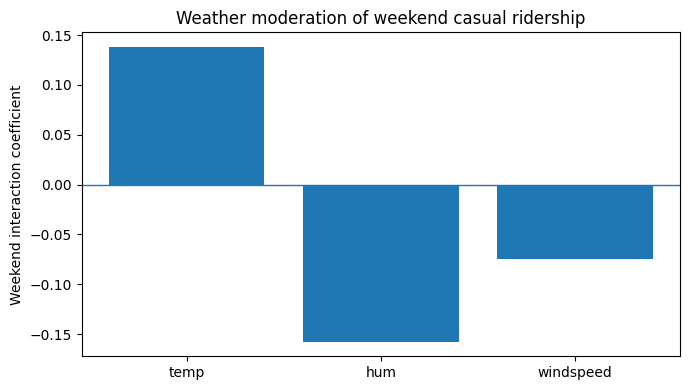

In [4]:
tr = train_2011.copy()
te = test_2012.copy()
weather_vars = ["temp", "hum", "windspeed"]

for variable in weather_vars:
    mean = tr[variable].mean()
    std = tr[variable].std()
    tr[f"z_{variable}"] = (tr[variable] - mean) / std
    te[f"z_{variable}"] = (te[variable] - mean) / std
    tr[f"weekend_x_z_{variable}"] = tr["weekend"] * tr[f"z_{variable}"]
    te[f"weekend_x_z_{variable}"] = te["weekend"] * te[f"z_{variable}"]

weekend_formula = (
    "np.log1p(casual) ~ weekend + C(hr) + C(season) + C(mnth) + C(weekday) + "
    "workingday + holiday + C(weathersit) + z_temp + z_hum + z_windspeed + "
    "weekend_x_z_temp + weekend_x_z_hum + weekend_x_z_windspeed"
)
weekend_model = smf.ols(weekend_formula, data=tr).fit()
weekend_pred = weekend_model.predict(te)

interaction_rows = []
for variable in weather_vars:
    term = f"weekend_x_z_{variable}"
    interaction_rows.append({
        "variable": variable,
        "weekend_interaction_coefficient": weekend_model.params[term],
        "p_value": weekend_model.pvalues[term],
    })
interaction_df = pd.DataFrame(interaction_rows)
print(f"2012 R² on log1p(casual): {r2_score(np.log1p(te['casual']), weekend_pred):.3f}")
display(interaction_df.reindex(interaction_df["weekend_interaction_coefficient"].abs().sort_values(ascending=False).index))

plt.figure(figsize=(7, 4))
plt.bar(interaction_df["variable"], interaction_df["weekend_interaction_coefficient"])
plt.axhline(0, linewidth=1)
plt.ylabel("Weekend interaction coefficient")
plt.title("Weather moderation of weekend casual ridership")
plt.tight_layout()
plt.savefig(FIG_DIR / "weekend_weather_interactions.png", dpi=160)
plt.show()

**Interpretation.** After standardization and mutual adjustment, humidity has the largest absolute weekend interaction, followed by temperature; wind speed is weaker. This differs from the original in-sample comparison and is a useful example of why evaluation design matters.

## 4. Is there evidence of concept drift between 2011 and 2012?

A stronger comparison is to estimate **within-2011 generalization** first, then compare it with performance on the next year. Five-fold cross-validation on 2011 provides the within-year baseline. The same pipeline is then fitted on all 2011 data and evaluated on all 2012 data.

A substantial drop is evidence consistent with temporal distribution/concept shift, although it does not identify the cause and should not be treated as a causal conclusion.

,evaluation,RMSE,R2
0,2011 5-fold CV,75.619114,0.680289
1,2012 held-out year,158.142558,0.426907


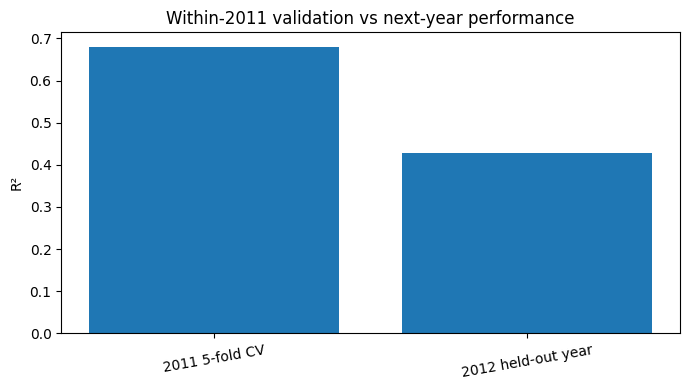

In [5]:
from sklearn.model_selection import KFold, cross_validate

categorical = ["hr", "season", "mnth", "weekday", "workingday", "holiday", "weathersit"]
numeric = ["temp", "hum", "windspeed"]
features = categorical + numeric

preprocess = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical),
    ("numeric", StandardScaler(), numeric),
])
drift_model = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0)),
])

bike_2011 = bike[bike["yr"] == 0]
bike_2012 = bike[bike["yr"] == 1]

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(
    drift_model,
    bike_2011[features],
    bike_2011["cnt"],
    cv=cv,
    scoring={"r2": "r2", "mse": "neg_mean_squared_error"},
)

cv_r2 = cv_results["test_r2"].mean()
cv_rmse = np.sqrt(-cv_results["test_mse"]).mean()

drift_model.fit(bike_2011[features], bike_2011["cnt"])
pred_2012 = drift_model.predict(bike_2012[features])
test_2012_r2 = r2_score(bike_2012["cnt"], pred_2012)
test_2012_rmse = mean_squared_error(bike_2012["cnt"], pred_2012) ** 0.5

drift_df = pd.DataFrame([
    {"evaluation": "2011 5-fold CV", "RMSE": cv_rmse, "R2": cv_r2},
    {"evaluation": "2012 held-out year", "RMSE": test_2012_rmse, "R2": test_2012_r2},
])
display(drift_df)

plt.figure(figsize=(7, 4))
plt.bar(drift_df["evaluation"], drift_df["R2"])
plt.ylabel("R²")
plt.title("Within-2011 validation vs next-year performance")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "concept_drift_comparison.png", dpi=160)
plt.show()

## 5. Predicting the hourly proportion of casual users

The target is `casual / cnt`. A regularized linear model is trained on 2011 and tested on 2012. Weekend × weather interaction terms are included explicitly, and their standardized coefficients are inspected.

2012 RMSE: 0.095
2012 R²:   0.437


,interaction,coefficient
0,temp_weekend,0.030831
1,hum_weekend,-0.023523
2,windspeed_weekend,-0.000524


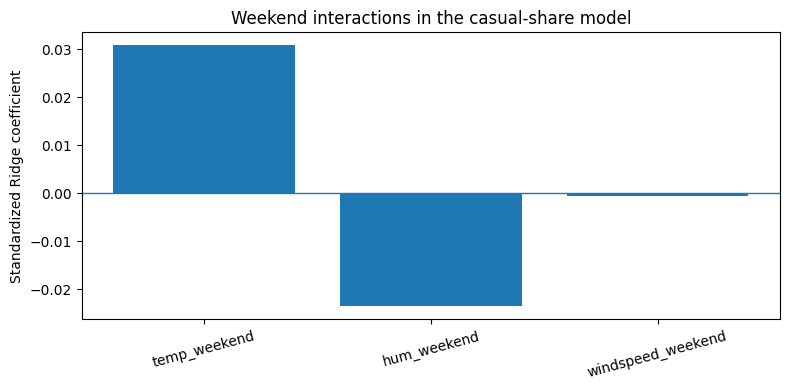

In [6]:
bike["casual_ratio"] = bike["casual"] / bike["cnt"]
bike["temp_weekend"] = bike["temp"] * bike["weekend"]
bike["hum_weekend"] = bike["hum"] * bike["weekend"]
bike["windspeed_weekend"] = bike["windspeed"] * bike["weekend"]

ratio_categorical = ["hr", "season", "mnth", "weekday", "workingday", "holiday", "weathersit"]
ratio_numeric = [
    "temp", "hum", "windspeed", "weekend",
    "temp_weekend", "hum_weekend", "windspeed_weekend",
]
ratio_features = ratio_categorical + ratio_numeric

ratio_preprocess = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", drop="first"), ratio_categorical),
    ("numeric", StandardScaler(), ratio_numeric),
])
ratio_model = Pipeline([
    ("preprocess", ratio_preprocess),
    ("model", Ridge(alpha=5.0)),
])

train_ratio = bike[bike["yr"] == 0]
test_ratio = bike[bike["yr"] == 1]
ratio_model.fit(train_ratio[ratio_features], train_ratio["casual_ratio"])
ratio_pred = ratio_model.predict(test_ratio[ratio_features])

print(f"2012 RMSE: {mean_squared_error(test_ratio['casual_ratio'], ratio_pred) ** 0.5:.3f}")
print(f"2012 R²:   {r2_score(test_ratio['casual_ratio'], ratio_pred):.3f}")

names = list(ratio_model.named_steps["preprocess"].get_feature_names_out())
coefs = ratio_model.named_steps["model"].coef_
interaction_terms = ["temp_weekend", "hum_weekend", "windspeed_weekend"]
ratio_interactions = pd.DataFrame({
    "interaction": interaction_terms,
    "coefficient": [coefs[names.index(f"numeric__{term}")] for term in interaction_terms],
})
display(ratio_interactions.reindex(ratio_interactions["coefficient"].abs().sort_values(ascending=False).index))

plt.figure(figsize=(8, 4))
plt.bar(ratio_interactions["interaction"], ratio_interactions["coefficient"])
plt.axhline(0, linewidth=1)
plt.ylabel("Standardized Ridge coefficient")
plt.title("Weekend interactions in the casual-share model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "casual_ratio_interactions.png", dpi=160)
plt.show()

## Takeaways

- Temperature effects are strongly hour-dependent and peak around the evening commute.
- Wind speed has a more negative association with casual than registered demand.
- In the corrected multivariate weekend model, humidity is the strongest standardized moderator, with temperature close behind.
- A 2011-trained model loses substantial performance on the matched 2012 period, consistent with temporal shift.
- The casual-user share is moderately predictable, and weekend × temperature/humidity interactions are more informative than weekend × wind speed.

These results are predictive/associational rather than causal.